<a href="https://colab.research.google.com/github/MarekSroka/SDA_projekty/blob/main/MS_Projekt_cars_06_02_22r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# test github

# Pobranie danych i wstępna analiza

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [ ]:
cars_data = pd.read_csv('drive/MyDrive/ML_uczenie_nadzorowane_regresja/car_price.csv')

In [ ]:
display(cars_data.head())
display(cars_data.tail())

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4
19236,45813273,470,753,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923 km,4.0,Automatic,Front,04-May,Left wheel,White,12


**df cars_data zawiera kolumny:**

Price - cena 

Levy - podatek(opłata wyrównawcza) 

Manufacturer - producent 

Model - model 

Prod. year - rok produkcji 

Category - typ pojazdu 

Leather interior - skórzana tapicaerka [0 1] 

Fuel type - rodzaj paliwa 

Engine volume - pojemność silnika 

Mileage - przebieg 

Cylinders - liczba cylindrów 

Gear box type - rodzaj skrzyni biegów 

Drive wheels - napęd 

Doors - liczba drzwi 

Color - kolor

Airbags - ilość poduszek powietrznych

In [ ]:
cars_data.shape

(19237, 18)

In [ ]:
cars_data.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')

In [ ]:
cars_data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [ ]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

Na chwilę obecną widzimy, że większość kolumn zawiera dane kategoryczne, część kolumn wymaga znacznego przetworzenia, żeby były użyteczne (np. 'Mileage' - wymagane oczyszczenie danych, zmianę typu danych na float)

- jest możliwość stworzenia dodakowych kolumn z już istniejących (wiek samochodu z roku produkcji, połączenia kolumn 

- niektóre kolumny zawierają mocno odstające dane ('Price', 'Mileage', 'Prod. year'), które należy przetworzyć/usunąć

- nie ma co prawda wartości NaN, jednak kolumna 'Levy' ma ponad 30% wartości '-' i jeszcze więcej '1' - cała kolumna do usunięcia

# Feature Engineering 

In [ ]:
car_data = cars_data.copy()

Stworzenie dodatkowej kolumny Turbo (0,1) zawierająca o silniku Turbo do kolumny Engine volume

In [ ]:
def turbo(value):
    if value[-5:] == 'Turbo':
        return 1
    else:
        return 0

car_data['Turbo']=car_data['Engine volume'].apply(turbo)

Kolumna Mileage - 

1)zamiana Mileage na float + bez 'km'

2) usunięcie wartości odstających pow 1 000 tys.


In [ ]:
car_data['Mileage']=car_data['Mileage'].str.replace(' ','')
car_data['Mileage']=car_data['Mileage'].str.replace('km','').astype('float')


In [ ]:
car_data.drop(car_data.index[car_data['Mileage'] > 750000 ],  axis=0, inplace=True)

**Stworzenie kolumny Car_age** z Prod. year
i usunięcie wartośći odstających pow 40 lat 

In [ ]:
def change_to_age(year):
  return 2022 - year

car_data['Car_age'] = car_data['Prod. year'].apply(change_to_age)

In [ ]:
car_data.describe()

,ID,Price,Prod. year,Mileage,Cylinders,Airbags,Turbo,Car_age
count,1.913800e+04,1.913800e+04,19138.000000,19138.000000,19138.000000,19138.000000,19138.000000,19138.000000
mean,4.557616e+07,1.860121e+04,2010.955586,139010.652419,4.583029,6.592329,0.100324,11.044414
std,9.379806e+05,1.910717e+05,5.624887,99321.404191,1.198939,4.321615,0.300439,5.624887
min,2.074688e+07,1.000000e+00,1939.000000,0.000000,1.000000,0.000000,0.000000,2.000000
25%,4.569691e+07,5.331000e+03,2009.000000,70000.000000,4.000000,4.000000,0.000000,7.000000
50%,4.577216e+07,1.317200e+04,2012.000000,125462.500000,4.000000,6.000000,0.000000,10.000000
75%,4.580204e+07,2.226600e+04,2015.000000,187334.000000,4.000000,12.000000,0.000000,13.000000
max,4.581665e+07,2.630750e+07,2020.000000,748742.000000,16.000000,16.000000,1.000000,83.000000


In [ ]:
car_data.drop(car_data.index[car_data['Car_age'] > 30 ],  axis=0, inplace=True)

In [ ]:
car_data.describe()

,ID,Price,Prod. year,Mileage,Cylinders,Airbags,Turbo,Car_age
count,1.904600e+04,1.904600e+04,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000
mean,4.557916e+07,1.865200e+04,2011.098971,139094.268298,4.583797,6.617400,0.100494,10.901029
std,9.048774e+05,1.915279e+05,5.161780,99106.980014,1.198007,4.312151,0.300665,5.161780
min,2.324298e+07,1.000000e+00,1992.000000,0.000000,1.000000,0.000000,0.000000,2.000000
25%,4.569614e+07,5.331000e+03,2009.000000,70048.000000,4.000000,4.000000,0.000000,7.000000
50%,4.577203e+07,1.317200e+04,2012.000000,125759.500000,4.000000,6.000000,0.000000,10.000000
75%,4.580205e+07,2.226600e+04,2015.000000,187331.250000,4.000000,12.000000,0.000000,13.000000
max,4.581665e+07,2.630750e+07,2020.000000,748742.000000,16.000000,16.000000,1.000000,30.000000


**Zmiana na wartości liczbowe** kolumn Manufacturer,Model, Category, Fuel type, Leather interior, Gear box type, Drive wheels, Doors, Wheel

In [ ]:
# Doors

car_data['Doors'].unique()
car_data['Doors'] = car_data['Doors'].str.replace('04-May', '2')
car_data['Doors'] = car_data['Doors'].str.replace('02-Mar', '1')
car_data['Doors'] = car_data['Doors'].str.replace('>5', '3')
car_data['Doors'] = car_data['Doors'].astype('int')

In [ ]:
#  funkcja zamiany stringa (kategoryczne) na liczbę

x={}
y=1
for element in car_data['Manufacturer'].unique():
    x[element]=y
    y+=1

In [ ]:
def category(value):
    return x[value]

In [ ]:
car_data['Manufacturer']=car_data['Manufacturer'].apply(category)

In [ ]:
# Model

x={}
y=1
for element in car_data['Model'].unique():
    x[element]=y
    y+=1

In [ ]:
car_data['Model']=car_data['Model'].apply(category)

In [ ]:
# Category

x={}
y=1
for element in car_data['Category'].unique():
    x[element]=y
    y+=1

car_data['Category']=car_data['Category'].apply(category)

In [ ]:
# Leather interior

x={}
y=1
for element in car_data['Leather interior'].unique():
    x[element]=y
    y+=1

car_data['Leather interior']=car_data['Leather interior'].apply(category)

In [ ]:
# Fuel type

x={}
y=1
for element in car_data['Fuel type'].unique():
    x[element]=y
    y+=1

car_data['Fuel type']=car_data['Fuel type'].apply(category)

In [ ]:
# Gear box type

x={}
y=1
for element in car_data['Gear box type'].unique():
    x[element]=y
    y+=1

car_data['Gear box type']=car_data['Gear box type'].apply(category)

In [ ]:
# Drive wheels

x={}
y=1
for element in car_data['Drive wheels'].unique():
    x[element]=y
    y+=1

car_data['Drive wheels']=car_data['Drive wheels'].apply(category)

In [ ]:
# Airbags

x={}
y=1
for element in car_data['Airbags'].unique():
    x[element]=y
    y+=1

car_data['Airbags']=car_data['Airbags'].apply(category)

In [ ]:
# Wheel

x={}
y=1
for element in car_data['Wheel'].unique():
    x[element]=y
    y+=1

car_data['Wheel']=car_data['Wheel'].apply(category)

In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age
count,1.904600e+04,1.904600e+04,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000
mean,4.557916e+07,1.865200e+04,8.100231,156.550352,2011.098971,2.686443,1.269978,2.273023,139094.268298,4.583797,1.514701,1.905229,1.967395,1.077182,3.649533,0.100494,10.901029
std,9.048774e+05,1.915279e+05,6.715951,276.811413,5.161780,1.711104,0.443960,1.100473,99106.980014,1.198007,0.937013,0.564828,0.211354,0.266886,2.316170,0.300665,5.161780
min,2.324298e+07,1.000000e+00,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000
25%,4.569614e+07,5.331000e+03,5.000000,10.000000,2009.000000,1.000000,1.000000,2.000000,70048.000000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000
50%,4.577203e+07,1.317200e+04,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,125759.500000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000
75%,4.580205e+07,2.226600e+04,10.000000,158.000000,2015.000000,3.000000,2.000000,3.000000,187331.250000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,13.000000
max,4.581665e+07,2.630750e+07,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,748742.000000,16.000000,4.000000,3.000000,3.000000,2.000000,17.000000,1.000000,30.000000


Stworzenie nowej kolumny **Vol per cylinder** z kolumn Engine volume / Cylinders. Kolumna Engine volume wymaga wcześniejszego przetworzenia.

In [ ]:
car_data['Engine volume'] = car_data['Engine volume'].str.replace('Turbo','').astype('float')


In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age
count,1.904600e+04,1.904600e+04,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000,19046.000000
mean,4.557916e+07,1.865200e+04,8.100231,156.550352,2011.098971,2.686443,1.269978,2.273023,2.309792,139094.268298,4.583797,1.514701,1.905229,1.967395,1.077182,3.649533,0.100494,10.901029
std,9.048774e+05,1.915279e+05,6.715951,276.811413,5.161780,1.711104,0.443960,1.100473,0.877381,99106.980014,1.198007,0.937013,0.564828,0.211354,0.266886,2.316170,0.300665,5.161780
min,2.324298e+07,1.000000e+00,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000
25%,4.569614e+07,5.331000e+03,5.000000,10.000000,2009.000000,1.000000,1.000000,2.000000,1.800000,70048.000000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000
50%,4.577203e+07,1.317200e+04,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,2.000000,125759.500000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000
75%,4.580205e+07,2.226600e+04,10.000000,158.000000,2015.000000,3.000000,2.000000,3.000000,2.500000,187331.250000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,13.000000
max,4.581665e+07,2.630750e+07,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,20.000000,748742.000000,16.000000,4.000000,3.000000,3.000000,2.000000,17.000000,1.000000,30.000000


In [ ]:
car_data.drop(car_data.index[car_data['Engine volume'] == 0 ],  axis=0, inplace=True)

In [ ]:
car_data['Vol per cylinder']=car_data['Cylinders']/car_data['Engine volume']

In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,1.903600e+04,1.903600e+04,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000,19036.000000
mean,4.557905e+07,1.865243e+04,8.098550,156.585102,2011.097552,2.686331,1.270067,2.272957,2.311005,139119.970319,4.583578,1.514972,1.905022,1.967378,1.077222,3.649926,0.100546,10.902448,2.119261
std,9.051024e+05,1.915777e+05,6.713074,276.866879,5.162451,1.711195,0.444006,1.100367,0.876013,99119.717809,1.197889,0.937185,0.564713,0.211408,0.266951,2.316296,0.300735,5.162451,0.758883
min,2.324298e+07,1.000000e+00,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.100000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.158730
25%,4.569598e+07,5.331000e+03,5.000000,10.000000,2009.000000,1.000000,1.000000,2.000000,1.800000,70060.000000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000,1.714286
50%,4.577202e+07,1.317200e+04,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,2.000000,125908.000000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000,2.000000
75%,4.580204e+07,2.226600e+04,10.000000,158.000000,2015.000000,3.000000,2.000000,3.000000,2.500000,187334.000000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,13.000000,2.400000
max,4.581665e+07,2.630750e+07,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,20.000000,748742.000000,16.000000,4.000000,3.000000,3.000000,2.000000,17.000000,1.000000,30.000000,30.000000


In [ ]:
car_data.drop(car_data.index[car_data['Vol per cylinder'] > 5 ],  axis=0, inplace=True)


In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,1.896400e+04,1.896400e+04,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000,18964.000000
mean,4.557905e+07,1.867800e+04,8.095128,156.247258,2011.102141,2.687513,1.269880,2.274309,2.316610,139111.644853,4.576250,1.514923,1.904714,1.967676,1.076883,3.650179,0.099768,10.897859,2.088184
std,9.059666e+05,1.919344e+05,6.711180,276.466648,5.161859,1.712596,0.443909,1.100331,0.871982,99074.676288,1.168293,0.936940,0.564596,0.210616,0.266412,2.316324,0.299698,5.161859,0.468014
min,2.324298e+07,1.000000e+00,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.158730
25%,4.569579e+07,5.488000e+03,5.000000,10.000000,2009.000000,1.000000,1.000000,2.000000,1.800000,70095.250000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000,1.714286
50%,4.577207e+07,1.317200e+04,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,2.000000,125927.000000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000,2.000000
75%,4.580205e+07,2.229275e+04,10.000000,158.000000,2015.000000,3.000000,2.000000,3.000000,2.500000,187312.000000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,13.000000,2.352941
max,4.581665e+07,2.630750e+07,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,20.000000,748742.000000,16.000000,4.000000,3.000000,3.000000,2.000000,17.000000,1.000000,30.000000,5.000000


**Usunięcie wartości skrajnych w kol. Price**

In [ ]:
car_data.drop(car_data.index[car_data['Price'] > 450000 ],  axis=0, inplace=True)


In [ ]:
car_data.drop(car_data.index[car_data['Price'] < 250 ],  axis=0, inplace=True)

In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,1.825200e+04,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000,18252.000000
mean,4.560847e+07,17878.792790,8.146669,158.826430,2011.127055,2.701786,1.267751,2.289009,2.314097,138928.102400,4.566130,1.524162,1.911133,1.966415,1.072266,3.664749,0.102235,10.872945,2.083424
std,7.455731e+05,18305.750905,6.742232,278.849358,5.190441,1.719459,0.442799,1.103699,0.865469,99167.389697,1.163081,0.943774,0.563334,0.212534,0.258935,2.311712,0.302966,5.190441,0.462318
min,2.436776e+07,250.000000,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.158730
25%,4.571497e+07,6586.000000,5.000000,10.000000,2009.000000,1.000000,1.000000,2.000000,1.800000,70000.000000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000,1.714286
50%,4.577324e+07,13799.000000,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,2.000000,125000.000000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000,2.000000
75%,4.580223e+07,22894.000000,10.000000,165.250000,2015.000000,3.000000,2.000000,3.000000,2.500000,186005.000000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,13.000000,2.352941
max,4.581665e+07,308906.000000,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,20.000000,748742.000000,16.000000,4.000000,3.000000,3.000000,2.000000,17.000000,1.000000,30.000000,5.000000


**Usunięcie odstających wartości w kol. 'Airbags'**

In [ ]:
car_data.drop(car_data.index[car_data['Airbags'] > 7 ],  axis=0, inplace=True)

In [ ]:
car_data.describe()

,ID,Price,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,1.778100e+04,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000
mean,4.560862e+07,17807.697317,8.114392,156.786176,2011.211237,2.696924,1.259884,2.293178,2.315061,139067.532141,4.563073,1.506271,1.908442,1.967325,1.070412,3.465441,0.098701,10.788763,2.081206
std,7.504927e+05,18043.743765,6.722991,276.631683,5.127424,1.720251,0.438583,1.108477,0.866368,99500.609743,1.156546,0.931590,0.560559,0.209184,0.255848,1.961583,0.298268,5.127424,0.459610
min,2.436776e+07,250.000000,1.000000,1.000000,1992.000000,1.000000,1.000000,1.000000,0.500000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.158730
25%,4.571508e+07,6429.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,2.000000,1.800000,70000.000000,4.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000,1.714286
50%,4.577289e+07,13799.000000,6.000000,43.000000,2012.000000,3.000000,1.000000,2.000000,2.000000,125000.000000,4.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000,2.000000
75%,4.580230e+07,22894.000000,10.000000,158.000000,2015.000000,3.000000,2.000000,3.000000,2.500000,186005.000000,4.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,12.000000,2.352941
max,4.581665e+07,308906.000000,62.000000,1554.000000,2020.000000,11.000000,2.000000,7.000000,20.000000,748742.000000,12.000000,4.000000,3.000000,3.000000,2.000000,7.000000,1.000000,30.000000,5.000000


**Usunięcie  kolumn:**
- ID (zbędna), 
- Levy (brakujące wartości),
-  Prod. year (stworzona z niej kolumna Car_age jest bardziej wartościowa),
- Engine volume, Cylinders (stworzona z nich 1 kolumna Vol per cylinder)
- Model (kolumna danych kat, zawiera zbyt dużo wartości

In [ ]:
car_data.drop(columns=['ID', 'Levy', 'Prod. year', 'Engine volume', 'Cylinders', 'Model', 'Color'], axis=1, inplace=True)
car_data.head()

,Price,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
0,13328,1,1,1,1,186005.0,1,1,2,1,1,0,12,1.714286
1,16621,2,1,2,2,192000.0,2,1,2,1,2,0,11,2.000000
2,8467,3,2,2,2,200000.0,3,2,2,2,3,0,16,3.076923
3,3607,4,1,1,1,168966.0,1,1,2,1,4,0,11,1.600000
4,11726,3,2,1,2,91901.0,1,2,2,1,5,0,8,3.076923


**wersja DF car_data przed normalizacją kolumn liczbowych**

In [ ]:
car_data = car_data.reset_index()

In [ ]:
display(car_data.head())
print(car_data.info())
display(car_data.describe())

,index,Price,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
0,0,13328,1,1,1,1,186005.0,1,1,2,1,1,0,12,1.714286
1,1,16621,2,1,2,2,192000.0,2,1,2,1,2,0,11,2.000000
2,2,8467,3,2,2,2,200000.0,3,2,2,2,3,0,16,3.076923
3,3,3607,4,1,1,1,168966.0,1,1,2,1,4,0,11,1.600000
4,4,11726,3,2,1,2,91901.0,1,2,2,1,5,0,8,3.076923


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17781 entries, 0 to 17780
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             17781 non-null  int64  
 1   Price             17781 non-null  int64  
 2   Manufacturer      17781 non-null  int64  
 3   Category          17781 non-null  int64  
 4   Leather interior  17781 non-null  int64  
 5   Fuel type         17781 non-null  int64  
 6   Mileage           17781 non-null  float64
 7   Gear box type     17781 non-null  int64  
 8   Drive wheels      17781 non-null  int64  
 9   Doors             17781 non-null  int64  
 10  Wheel             17781 non-null  int64  
 11  Airbags           17781 non-null  int64  
 12  Turbo             17781 non-null  int64  
 13  Car_age           17781 non-null  int64  
 14  Vol per cylinder  17781 non-null  float64
dtypes: float64(2), int64(13)
memory usage: 2.0 MB
None


,index,Price,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000
mean,9625.439627,17807.697317,8.114392,2.696924,1.259884,2.293178,139067.532141,1.506271,1.908442,1.967325,1.070412,3.465441,0.098701,10.788763,2.081206
std,5555.802370,18043.743765,6.722991,1.720251,0.438583,1.108477,99500.609743,0.931590,0.560559,0.209184,0.255848,1.961583,0.298268,5.127424,0.459610
min,0.000000,250.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.158730
25%,4822.000000,6429.000000,5.000000,1.000000,1.000000,2.000000,70000.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,7.000000,1.714286
50%,9628.000000,13799.000000,6.000000,3.000000,1.000000,2.000000,125000.000000,1.000000,2.000000,2.000000,1.000000,4.000000,0.000000,10.000000,2.000000
75%,14431.000000,22894.000000,10.000000,3.000000,2.000000,3.000000,186005.000000,2.000000,2.000000,2.000000,1.000000,5.000000,0.000000,12.000000,2.352941
max,19236.000000,308906.000000,62.000000,11.000000,2.000000,7.000000,748742.000000,4.000000,3.000000,3.000000,2.000000,7.000000,1.000000,30.000000,5.000000


# Kolejna analiza danych ( wykresy)



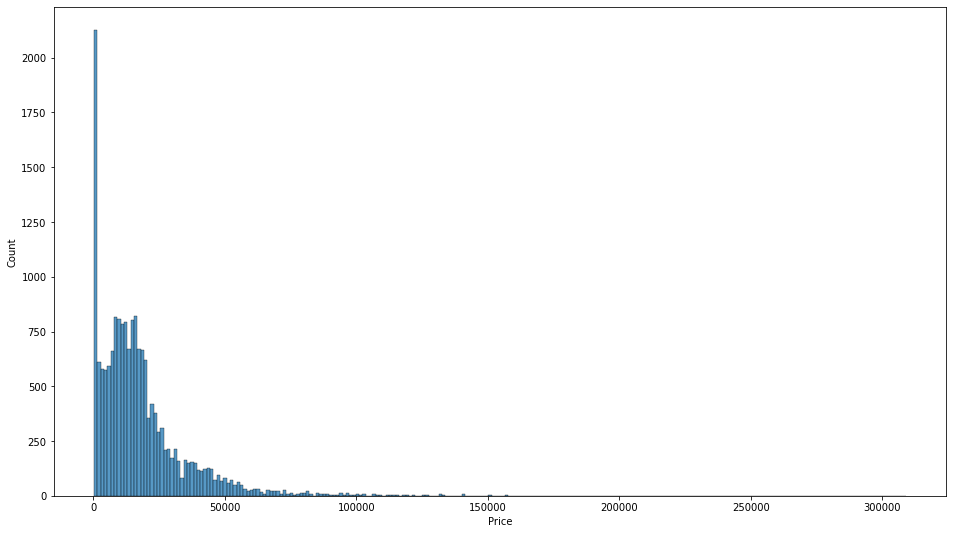

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 9))
sns.histplot(car_data['Price'])
plt.show()

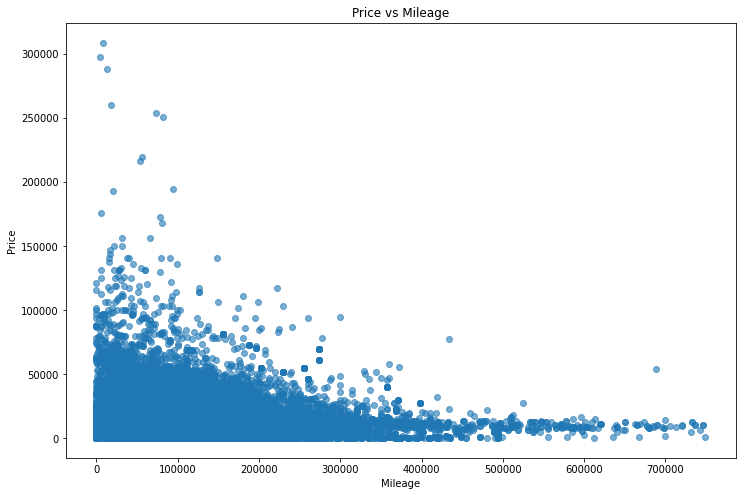

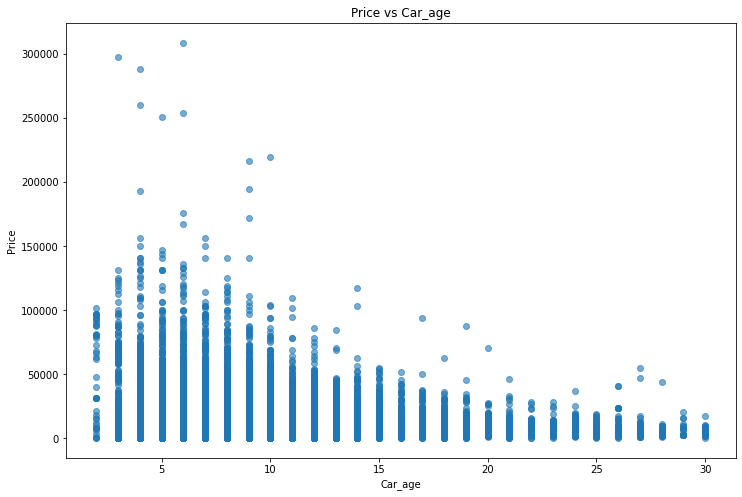

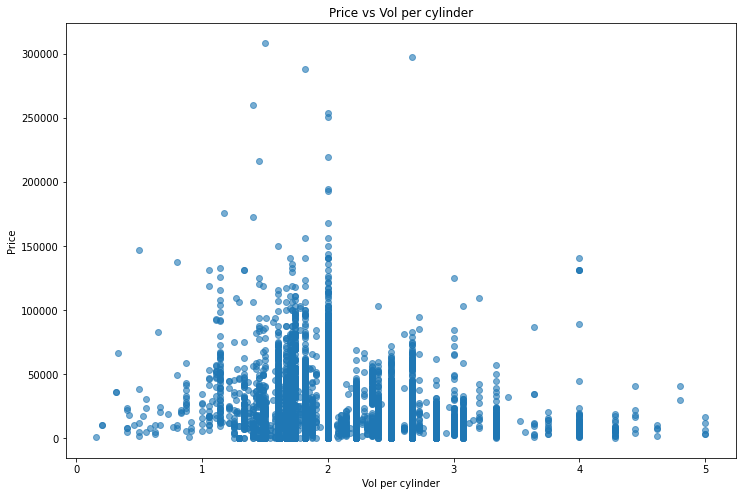

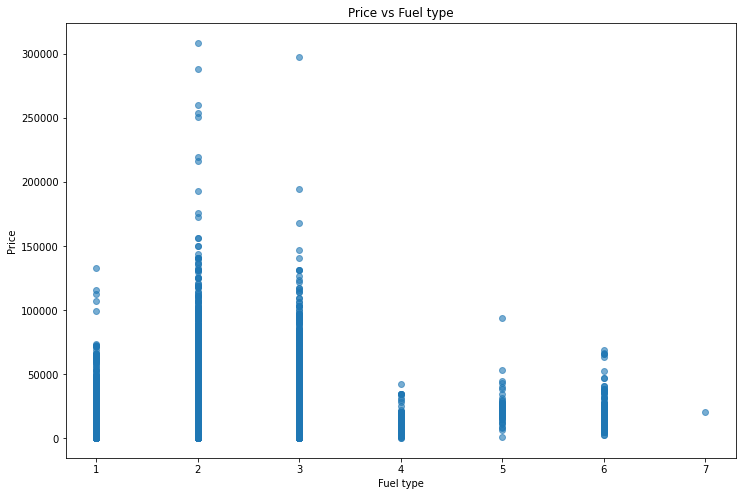

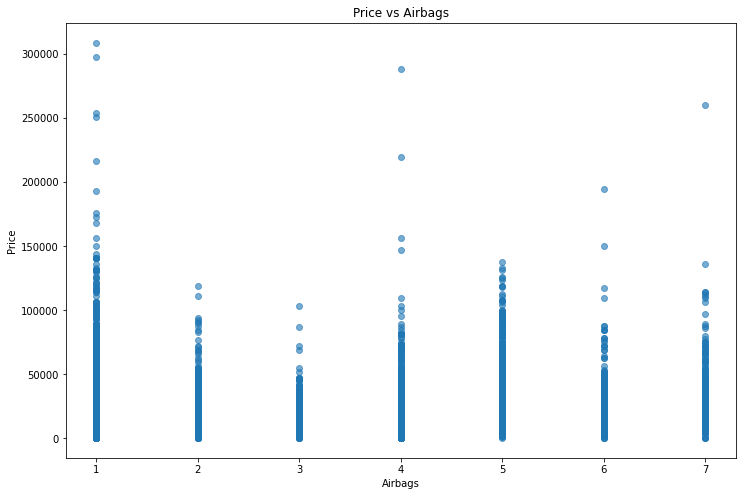

In [ ]:
data = car_data

numeric_features = ['Mileage' ,'Car_age', 'Vol per cylinder', 'Fuel type', 'Airbags']
categorical_features = ['Manufacturer', 'Category', 'Leather interior', 'Gear box type', 'Drive wheels', 'Doors' , 'Wheel', 'Turbo']

target='Price'

for numeric_feature in numeric_features:
  fig = plt.figure(figsize=(12,8))
  plt.scatter(data[numeric_feature], data[target], alpha=0.6)
  plt.xlabel(numeric_feature)
  plt.ylabel('Price')
  plt.title(f'Price vs {numeric_feature}')
  plt.show()


In [ ]:
data[[target] + numeric_features].corr()

,Price,Mileage,Car_age,Vol per cylinder,Fuel type,Airbags
Price,1.000000,-0.219172,-0.305061,-0.109806,0.073160,0.156937
Mileage,-0.219172,1.000000,0.219683,-0.112358,0.219645,-0.017373
Car_age,-0.305061,0.219683,1.000000,0.064242,0.092545,0.117135
Vol per cylinder,-0.109806,-0.112358,0.064242,1.000000,-0.094364,0.178794
Fuel type,0.073160,0.219645,0.092545,-0.094364,1.000000,0.239229
Airbags,0.156937,-0.017373,0.117135,0.178794,0.239229,1.000000


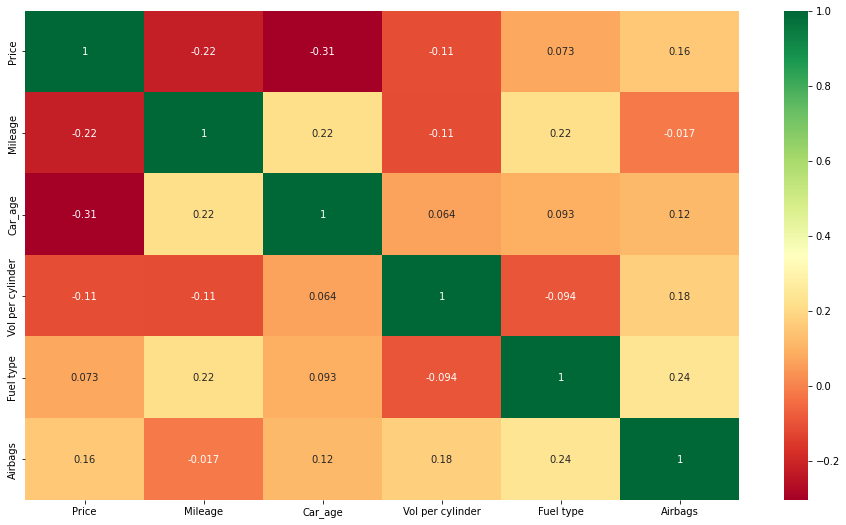

In [ ]:
plt.figure(figsize=(16,9))
ax = sns.heatmap(data[[target] + numeric_features].corr(), cmap='RdYlGn', annot=True)

plt.show()

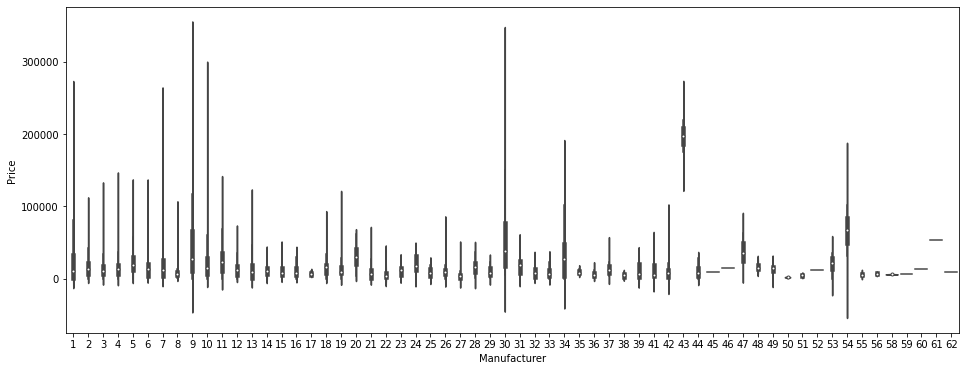

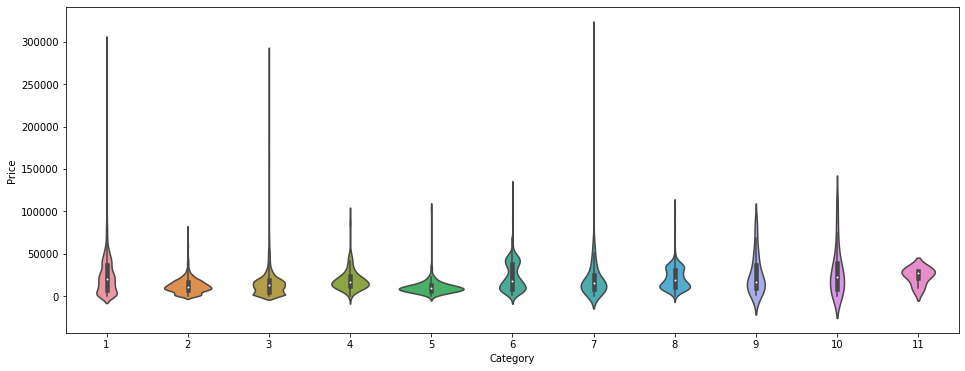

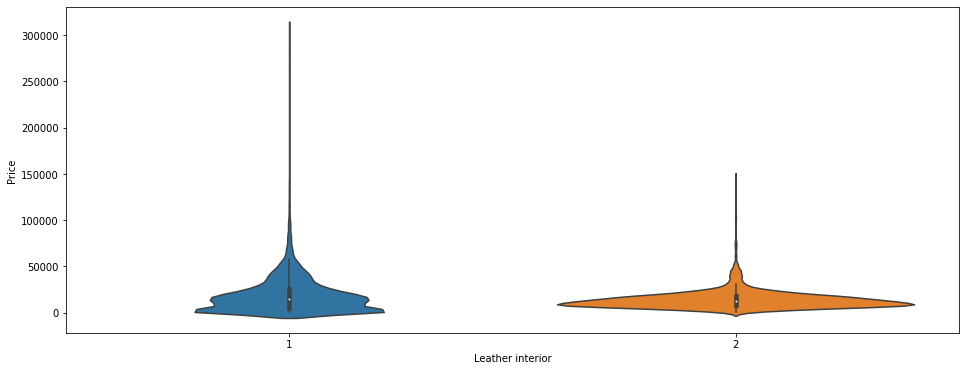

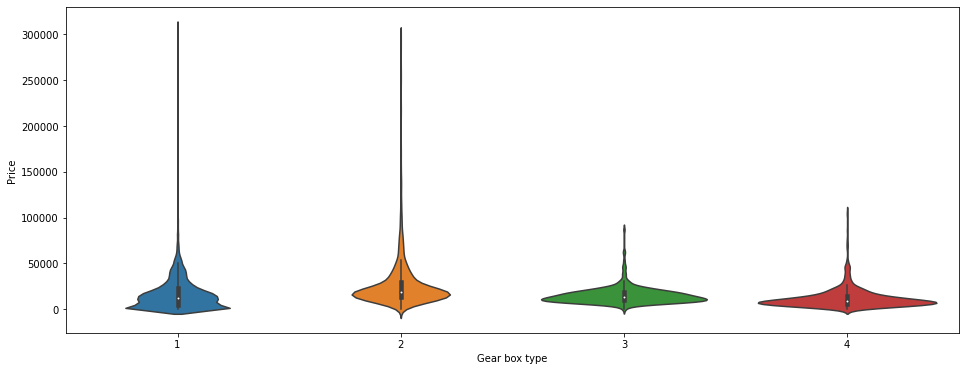

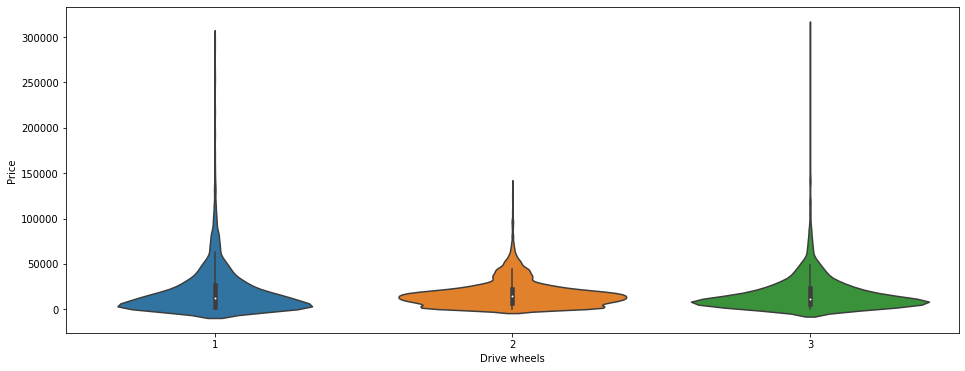

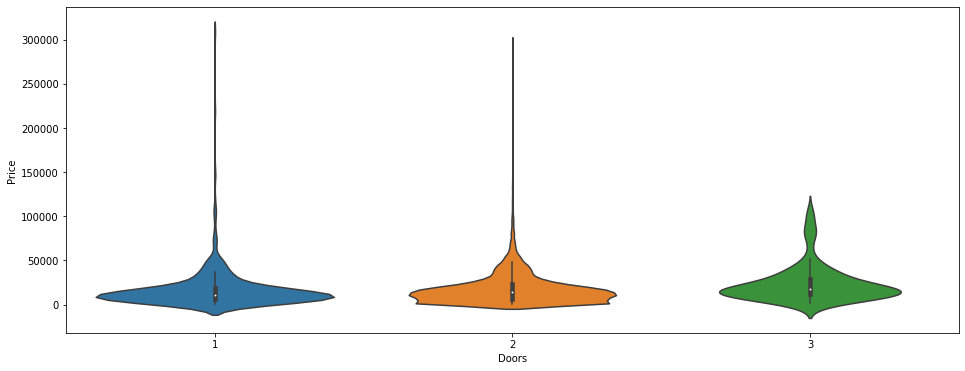

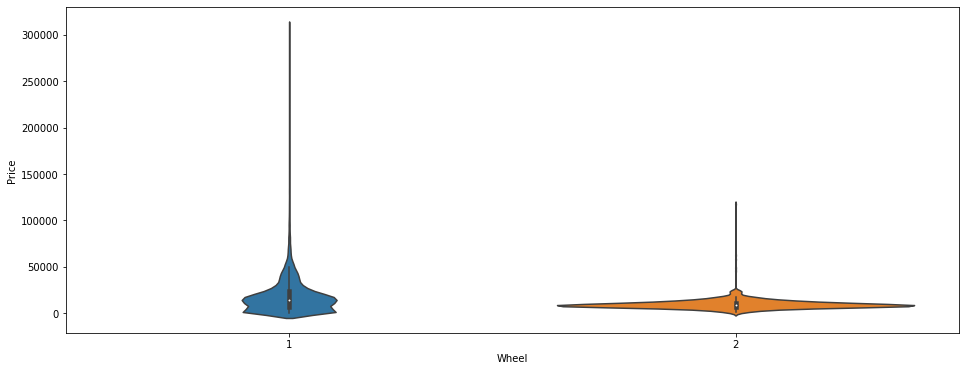

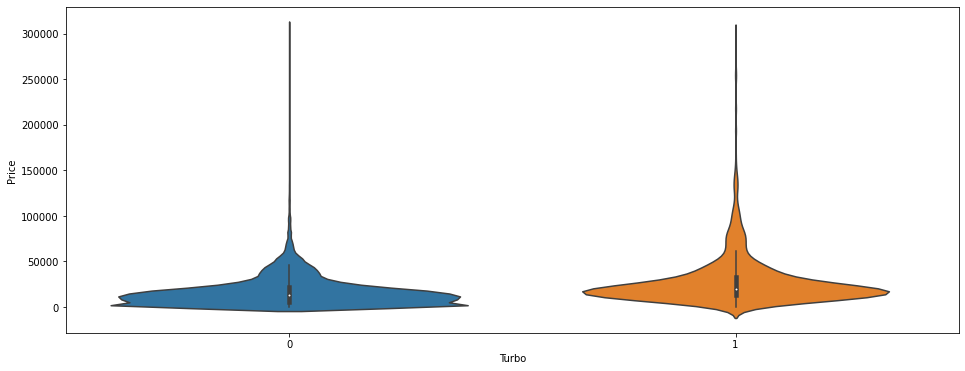

In [ ]:
for categorical_feature in categorical_features:
  plt.figure(figsize=(16,6))
  sns.violinplot(y=data[target], x=data[categorical_feature])
  plt.show()

**1. Podział danych na treningowe i testowe**
 
**2. Normalizacja danych z kolumn liczbowych** - kolumny Mileage, Airbags, Car_age, Vol per cylinder

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# poprawić !!! - podział danych

In [ ]:
car_data_norm = car_data.copy()  # wersja 3 - do normalizacji i modelu

# 1  podział danych train test


# 2 

scaler = MinMaxScaler()

scaler.fit(car_data_norm[['Airbags', 'Car_age', 'Mileage', 'Vol per cylinder']])

scaled = scaler.fit_transform(car_data_norm[['Airbags', 'Car_age', 'Mileage', 'Vol per cylinder']])

scaled_df = pd.DataFrame(scaled, columns=['Airbags', 'Car_age', 'Mileage', 'Vol per cylinder'] )

scaled_df

,Airbags,Car_age,Mileage,Vol per cylinder
0,0.000000,0.357143,0.248423,0.321311
1,0.166667,0.321429,0.256430,0.380328
2,0.333333,0.500000,0.267115,0.602774
3,0.500000,0.321429,0.225667,0.297705
4,0.666667,0.214286,0.122741,0.602774
...,...,...,...,...
17776,0.000000,0.250000,0.143975,0.321311
17777,0.166667,0.321429,0.215829,0.311475
17778,0.666667,0.357143,0.155414,0.380328
17779,0.666667,0.464286,0.068459,0.380328


In [ ]:
car_data_norm['Mileage'] = scaled_df['Mileage']
car_data_norm['Airbags'] = scaled_df['Airbags']
car_data_norm['Car_age'] = scaled_df['Car_age']
car_data_norm['Vol per cylinder'] = scaled_df['Vol per cylinder']

In [ ]:
display(car_data_norm)
display(car_data_norm.describe())

,index,Price,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
0,0,13328,1,1,1,1,0.248423,1,1,2,1,0.000000,0,0.357143,0.321311
1,1,16621,2,1,2,2,0.256430,2,1,2,1,0.166667,0,0.321429,0.380328
2,2,8467,3,2,2,2,0.267115,3,2,2,2,0.333333,0,0.500000,0.602774
3,3,3607,4,1,1,1,0.225667,1,1,2,1,0.500000,0,0.321429,0.297705
4,4,11726,3,2,1,2,0.122741,1,2,2,1,0.666667,0,0.214286,0.602774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17776,19231,5802,7,3,1,3,0.143975,1,3,2,1,0.000000,0,0.250000,0.321311
17777,19233,15681,5,3,1,2,0.215829,2,2,2,1,0.166667,0,0.321429,0.311475
17778,19234,26108,5,1,1,3,0.155414,1,2,2,1,0.666667,0,0.357143,0.380328
17779,19235,5331,2,1,1,3,0.068459,1,2,2,1,0.666667,0,0.464286,0.380328


,index,Price,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
count,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000,17781.000000
mean,9625.439627,17807.697317,8.114392,2.696924,1.259884,2.293178,0.185735,1.506271,1.908442,1.967325,1.070412,0.410907,0.098701,0.313884,0.397101
std,5555.802370,18043.743765,6.722991,1.720251,0.438583,1.108477,0.132890,0.931590,0.560559,0.209184,0.255848,0.326930,0.298268,0.183122,0.094936
min,0.000000,250.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4822.000000,6429.000000,5.000000,1.000000,1.000000,2.000000,0.093490,1.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.178571,0.321311
50%,9628.000000,13799.000000,6.000000,3.000000,1.000000,2.000000,0.166947,1.000000,2.000000,2.000000,1.000000,0.500000,0.000000,0.285714,0.380328
75%,14431.000000,22894.000000,10.000000,3.000000,2.000000,3.000000,0.248423,2.000000,2.000000,2.000000,1.000000,0.666667,0.000000,0.357143,0.453230
max,19236.000000,308906.000000,62.000000,11.000000,2.000000,7.000000,1.000000,4.000000,3.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000


# Podział danych, trenowanie modelu regresji

In [ ]:
data = car_data_norm

In [ ]:
data.drop('index', inplace=True, axis=1)

In [ ]:
X = data.drop([target], axis=1)
display(X.iloc[:3])

y = data[target]
display(y.iloc[:3])

,Manufacturer,Category,Leather interior,Fuel type,Mileage,Gear box type,Drive wheels,Doors,Wheel,Airbags,Turbo,Car_age,Vol per cylinder
0,1,1,1,1,0.248423,1,1,2,1,0.000000,0,0.357143,0.321311
1,2,1,2,2,0.256430,2,1,2,1,0.166667,0,0.321429,0.380328
2,3,2,2,2,0.267115,3,2,2,2,0.333333,0,0.500000,0.602774


0    13328
1    16621
2     8467
Name: Price, dtype: int64

**podział na dane treningowe i testowe**

In [ ]:
# from sklearn.model_selection import train_test_split

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6022) # czy będzie używane ?

Przygotowanie danych poprzez Krosswalidację

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=6022)

for train, test in cv.split(X, y):
  X_train, y_train = X.iloc[train], y.iloc[train]
  X_test, y_test = X.iloc[test], y.iloc[test]

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_reg_model=LinearRegression()
lin_reg_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_lr_predict_train = lin_reg_model.predict(X_train)
y_lr_predict_test = lin_reg_model.predict(X_test)

# Ocena modelu regresji 



Baseline

In [ ]:
from sklearn.dummy import DummyRegressor

In [ ]:
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

DummyRegressor()

In [ ]:
y_train_dummy = dummy_model.predict(X_train)
y_test_dummy = dummy_model.predict(X_test)

R^2

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
print(f'Dummy Train R^2: {r2_score(y_train, y_train_dummy)}')   
print(f'RL Model Train R^2: {r2_score(y_train, y_lr_predict_train)}')

Dummy Train R^2: 0.0
RL Model Train R^2: 0.24907185494675788


MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
print(f'Dummy MAE: {mean_absolute_error(y_test, y_test_dummy)}')
print(f'RL Model MAE: {mean_absolute_error(y_test, y_lr_predict_test)}')

Dummy MAE: 11788.526862862538
RL Model MAE: 10304.319354368205


RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

In [ ]:
err=np.sqrt(mean_squared_error(y_test, y_lr_predict_test))
print(f'RMSE={err}')

RMSE=14253.991966273874


In [ ]:
print(f'Dummy RMSE: {mean_squared_error(y_test, y_test_dummy, squared=False)}')
print(f'Model RMSE: {err}')

Dummy RMSE: 16161.16624237595
Model RMSE: 14253.991966273874


In [ ]:
price_std = data['Price'].std()
price_mean = data['Price'].mean()

print(f'Average price: {price_mean}')
print(f'Std_of_price: {price_std}')
print(f'Model RMSE: {mean_squared_error(y_test, y_lr_predict_test, squared=False)}')

Average price: 17807.697317361228
Std_of_price: 18043.7437651401
Model RMSE: 14253.991966273874


Średnia cena pojazdu ze zbioru to ?? , odchylenie std ?? zatem ?? // WNIOSKI !!

# Tree model i jego ocena

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
tree_model=DecisionTreeRegressor()
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(min_samples_split=20)

In [ ]:
y_tm_predict_train = tree_model.predict(X_train)
y_tm_predict_test = tree_model.predict(X_test)

MAE

In [ ]:
print(f'Dummy MAE: {mean_absolute_error(y_test, y_test_dummy)}')
print(f'Model tree MAE: {mean_absolute_error(y_test, y_tm_predict_test)}')

Dummy MAE: 11788.526862862538
Model tree MAE: 5894.0888106565635


RMSE

In [ ]:
err2=np.sqrt(mean_squared_error(y_test, y_tm_predict_test))
print(f'RMSE={err2}')

RMSE=12120.473412766914


Duża rozbieżność pomiędzy MAE i RMSE wskazuje, że w danych jest jeszcze spory poziom wartości odstających

# Porównanie działania 2 modeli

**Wykres reszt**

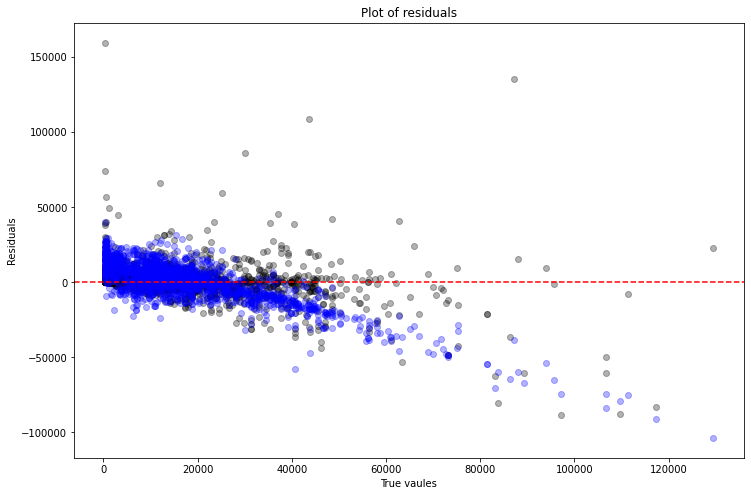

In [ ]:
plt.figure(figsize=(12, 8))

errors_lr = y_lr_predict_test - y_test
errors_tm = y_tm_predict_test - y_test

plt.scatter(y_test, errors_tm, color='k',alpha =0.3)
plt.scatter(y_test, errors_lr, color='b',alpha=0.3)

plt.xlabel('True vaules')
plt.ylabel('Residuals')
plt.title('Plot of residuals')

plt.axhline(0, color='red', linestyle='--')

plt.show()

Są widoczne zależności w rezyduach zatem mode nie jest w pełni wyjasniony.

**Histogramy reszt**

Histogram dla LR

LR Error mean: 592.4394375862274


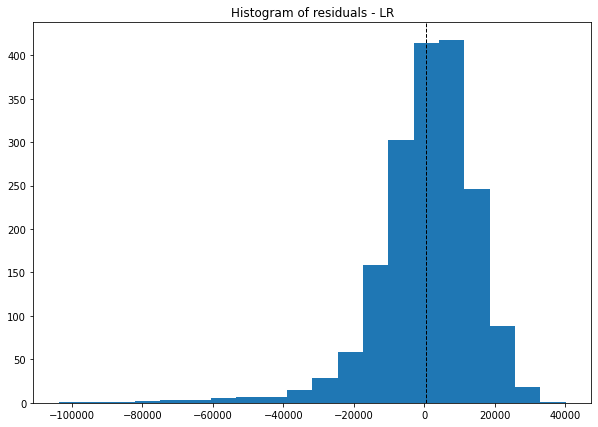

In [ ]:
plt.figure(figsize=(10, 7))

print(f'LR Error mean: {errors_lr.mean()}')

plt.hist(errors_lr, bins=20)
plt.axvline(errors_lr.mean(), color='k', linestyle='dashed', linewidth=1)
plt.title('Histogram of residuals - LR')

plt.show()

Histogram dla MT

TM Error mean: 418.41405683470185


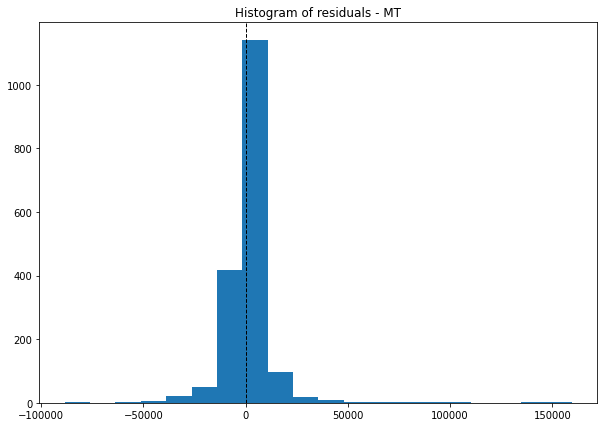

In [ ]:
plt.figure(figsize=(9, 7))

print(f'TM Error mean: {errors_tm.mean()}')

plt.hist(errors_tm, bins=20)
plt.axvline(errors_tm.mean(), color='k', linestyle='dashed', linewidth=1)
plt.title('Histogram of residuals - Decision')

plt.show()

In [ ]:
# do zadania

plt.figure(figsize=(10, 7))

print(f'TM Error mean: {errors_tm.mean()}')

plt.hist(errors_tm, bins=20)
plt.axvline(errors_tm.mean(), color='k', linestyle='dashed', linewidth=1)
plt.title('Histogram of residuals - MT')

plt.show()

# Strojenie hiperparametrów

**Decision Tree**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
dtm = DecisionTreeRegressor(min_samples_split=5, 
                            min_samples_leaf=5,
                            max_depth=4
                            )

In [ ]:
param_grid = {"criterion": ["squared_error", "absolute_error"],
              "max_depth" : [20, 22, 24],
              'min_samples_leaf' : [19, 20, 21],
              'min_samples_split' : [21, 22, 22]
              }
grid_cv_dtm = GridSearchCV(dtm, param_grid, cv=5)

grid_cv_dtm.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeRegressor(max_depth=4, min_samples_leaf=5,
                                             min_samples_split=5),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [20, 22, 24],
                         'min_samples_leaf': [19, 20, 21],
                         'min_samples_split': [21, 22, 22]})

Kilkukrotne sprawdzenie różnych zestawów parametrów dało optymalny wynik:

In [ ]:
print('Best min_samples_split:', grid_cv_dtm.best_estimator_.get_params()['min_samples_split'])
print('Best min_samples_leaf:', grid_cv_dtm.best_estimator_.get_params()['min_samples_leaf'])
print('Best max_depth:', grid_cv_dtm.best_estimator_.get_params()['max_depth'])

Best min_samples_split: 22
Best min_samples_leaf: 19
Best max_depth: 22


In [ ]:
final_mt = grid_cv_dtm.best_estimator_

In [ ]:
print(f'OLD MT RMSE:{err2}')
new_pred = final_mt.predict(X_test)
new_rmse=np.sqrt(mean_squared_error(y_test, new_pred))
print(f'New MT RMSE:{new_rmse}')

OLD MT RMSE:12120.473412766914
New MT RMSE:11374.320948418974


W Wyniku strojenia hiperparametrów dla Model Tree **RMSE** został poprawiony.

In [ ]:
# pipeline dla Model Tree

from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

from sklearn.model_selection import GridSearchCV  # sprawdzić czy się nie powtarza ?!

In [ ]:
numeric_features

In [ ]:
categorical_features

In [ ]:
numeric_transformer = Pipeline(steps=[
                                ('log_trasnformer', PowerTransformer()),
                               ('standardscaler', StandardScaler()), 
                               ('polynomialfeatures', PolynomialFeatures())
                               ])

In [ ]:
categorical_transformer = Pipeline(steps=[
                                  ('OHE', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', LinearRegression())])

print(final_pipeline.get_params().keys())

In [ ]:
display(X_train.head())
display(y_train.head())

In [ ]:
params = {'preprocessor__num__polynomialfeatures__degree': [1, 2, 3, 4, 5, 6]}

final_gridsearch = GridSearchCV(final_pipeline,
                                params, 
                                scoring='neg_mean_squared_error',
                                cv=10,
                                verbose=10)

final_gridsearch.fit(X_train, y_train)
print('\nBest hyperparameter:', final_gridsearch.best_params_)

final_model = final_gridsearch.best_estimator_

In [ ]:
# print(f'Old RMSE: {sqrt(mse)}')
new_predictions = final_model.predict(X_test)
new_mse = mean_squared_error(y_test, new_predictions)
print(f'RMSE: {sqrt(new_mse)}')